# Error Analysis

Notebook này dùng để phân tích lỗi detection có hệ thống:
- Vẽ ground truth box và predicted box trên cùng ảnh.
- Predicted box có class name và confidence score.
- Đếm lỗi theo loại: false negative, false positive, wrong class, poor localization, duplicate boxes.
- Liên hệ lỗi với dataset: class ít, object nhỏ, annotation khó, background giống object.
- Từ lỗi quan sát được, chọn thí nghiệm cải thiện phù hợp thay vì đổi model ngẫu nhiên.

In [4]:
from pathlib import Path
import sys

from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.notebook_helpers import (
    confusion_matrix_table,
    confusion_pairs_table,
    detection_error_table_readable,
    error_dataset_context_tables,
    error_guidance_table,
    load_prediction_analysis,
    per_class_ap_table,
    plot_confusion_matrix,
    plot_detection_errors,
    plot_per_class_ap,
    plot_threshold_tuning_heatmap,
    prediction_metrics_table,
    recommended_experiments_from_errors,
    show_prediction_analysis_slider,
    show_predictions_slider,
    tune_prediction_thresholds,
    )

RUN_NAME = "retina-hgnetb4v2-fullaugment"
RUN_RESULTS = PROJECT_ROOT / "saved_results" / RUN_NAME
ANALYSIS_DIR = RUN_RESULTS / "error_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS = RUN_RESULTS / "predictions.json"
RAW_PREDICTIONS = RUN_RESULTS / "predictions_raw.json"
GROUND_TRUTH = PROJECT_ROOT / "public/annotations/val.json"
VAL_IMAGES = PROJECT_ROOT / "public/val/images"
CLASSES = PROJECT_ROOT / "public/classes.json"

def save_dataframe(frame, filename):
    path = ANALYSIS_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    return path

def save_plot(artist, filename):
    path = ANALYSIS_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    figure = getattr(artist, "figure", artist)
    figure.savefig(path, dpi=150, bbox_inches="tight")
    return path

In [8]:
%cd ..
!WANDB_RUN_NAME={RUN_NAME} CUSTOM_MODEL=0 bash script.sh predict
%cd notebooks

/Users/ngocbao/Documents/Document/Semester6/Image Processing/Final
============ Prediction Session ============
image_source: public/val/images
num_images: 1500
output: saved_results/retina-hgnetb4v2-fullaugment/predictions.json
checkpoint: saved_results/retina-hgnetb4v2-fullaugment/checkpoints/best_model.pth
checkpoint_exists: True
classes: ["person", "car", "dog", "cat", "chair"]
device: mps
score_threshold: 0.05
nms_threshold: 0.4
model: retina hgnetv2_b4
custom_model: False
model_impl: retina
min_size: 512
max_size: 768
anchor_sizes: model_default
anchor_ratios: model_default
model_config_source: checkpoint
Traceback (most recent call last):
  File "/Users/ngocbao/Documents/Document/Semester6/Image Processing/Final/predict.py", line 219, in <module>
    main()
  File "/Users/ngocbao/Documents/Document/Semester6/Image Processing/Final/predict.py", line 178, in main
    model = create_detection_model(
            ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ngocbao/Documents/Document/Semes

## 1. Metric Tổng Quan Và AP Theo Class

Cell này cho biết chất lượng tổng quan trước khi đi vào từng loại lỗi. Nếu `mAP@0.5` ổn nhưng `mAP@0.75` thấp, thường có vấn đề localization.

In [6]:
analysis = load_prediction_analysis(PREDICTIONS, GROUND_TRUTH)
metrics_table = prediction_metrics_table(analysis)
per_class_table = per_class_ap_table(analysis)
display(metrics_table.round(4))
display(per_class_table.round(4))
save_dataframe(metrics_table, "prediction_metrics.csv")
save_dataframe(per_class_table, "per_class_ap.csv")
save_plot(plot_per_class_ap(analysis), "per_class_ap.png")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ngocbao/Documents/Document/Semester6/Image Processing/Final/saved_results/retina-hgnetb4v2-fullaugment/predictions.json'

## 2. Bảng Loại Lỗi Và Hướng Xử Lý

Bảng này là checklist để đọc lỗi và chọn thí nghiệm tiếp theo.

In [ ]:
error_guidance = error_guidance_table()
display(error_guidance)
save_dataframe(error_guidance, "error_guidance.csv")

,Loại lỗi,Dấu hiệu,Hướng xử lý
0,False Negative,Có object thật nhưng model không detect,"Giảm confidence threshold, tăng image size, th..."
1,False Positive,Model detect nhầm background,"Tăng confidence threshold, thêm ảnh negative, ..."
2,Wrong Class,Box đúng nhưng class sai,"Kiểm tra label, xử lý class imbalance, xem cla..."
3,Poor Localization,"Đúng class nhưng box lệch, mAP@0.75 thấp","Kiểm tra annotation, train lâu hơn với LR nhỏ,..."
4,Duplicate Boxes,Một object có nhiều predicted boxes,Điều chỉnh NMS threshold
5,Small Object Miss,Object nhỏ thường bị bỏ sót,"Tăng resolution, oversampling ảnh có object nhỏ"
6,Occlusion / Hard Background,Object bị che khuất hoặc background giống object,"Thêm dữ liệu tương tự, augmentation phù hợp"


PosixPath('/home/uet/edu_viettel/xla/IM-object-detection/saved_results/retina-resnet101-fullagment-oversampling-chairx2.5-512x768/error_analysis/error_guidance.csv')

## 3. Đếm Lỗi Theo Từng Loại

Các lỗi được quy đổi về tên dễ đọc:
- `false_negative`: object thật bị bỏ sót.
- `false_positive`: detect nhầm background.
- `wrong_class`: box overlap đúng nhưng class sai.
- `poor_localization`: đúng class nhưng IoU chưa đủ 0.5.
- `duplicate_boxes`: nhiều prediction cho cùng một object.

,error_type,raw_error_type,count
0,false_negative,missed_detection,396
1,false_positive,background_false_positive,386
2,poor_localization,localization_error,113
3,wrong_class,classification_error,78
4,duplicate_boxes,duplicate_detection,43


PosixPath('/home/uet/edu_viettel/xla/IM-object-detection/saved_results/retina-resnet101-fullagment-oversampling-chairx2.5-512x768/error_analysis/detection_errors.png')

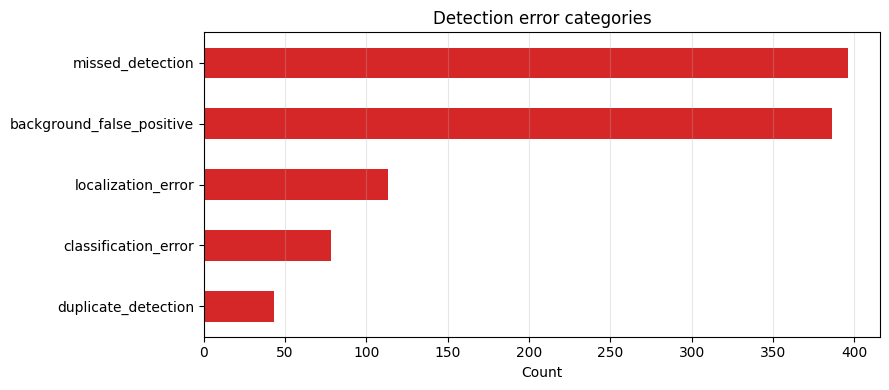

In [ ]:
error_counts = detection_error_table_readable(analysis)
display(error_counts)
save_dataframe(error_counts, "error_counts.csv")
save_plot(plot_detection_errors(analysis), "detection_errors.png")

## 4. Confusion Matrix Theo Class

Ma trận này match mỗi ground-truth object với prediction tốt nhất ở `IoU >= 0.5`, bất kể class. Nhờ đó có thể thấy class thật bị dự đoán thành class nào, hoặc bị `missed`. Hàng `background_fp` là prediction không match với object thật nào.


,person,car,dog,cat,chair,missed
person,865,0,5,1,10,193
car,2,229,0,0,0,52
dog,2,0,174,6,0,24
cat,0,0,9,150,0,17
chair,3,0,1,1,180,97
background_fp,245,97,69,39,157,0


,gt_class,predicted_class,count
0,background_fp,person,245
1,person,missed,193
2,background_fp,chair,157
3,chair,missed,97
4,background_fp,car,97
5,background_fp,dog,69
6,car,missed,52
7,background_fp,cat,39
8,dog,missed,24
9,cat,missed,17


PosixPath('/home/uet/edu_viettel/xla/IM-object-detection/saved_results/retina-resnet101-fullagment-oversampling-chairx2.5-512x768/error_analysis/confusion_matrix.png')

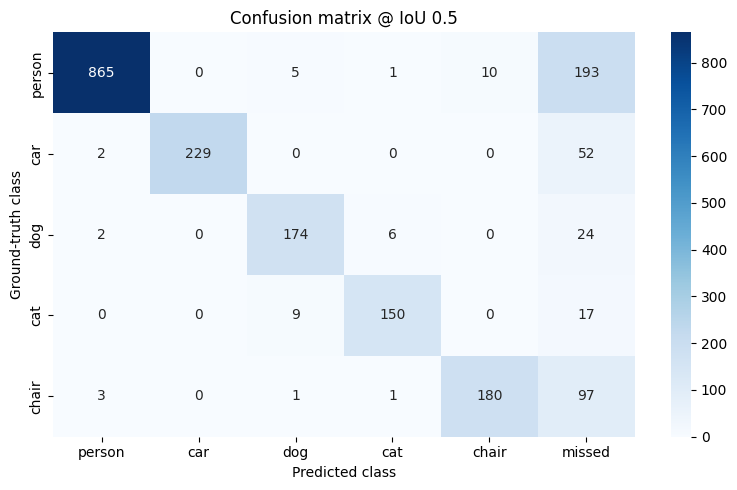

In [ ]:
confusion_matrix = confusion_matrix_table(analysis)
confusion_pairs = confusion_pairs_table(analysis, include_correct=False)

display(confusion_matrix)
display(confusion_pairs.head(20))

confusion_matrix.to_csv(ANALYSIS_DIR / "confusion_matrix.csv", index_label="gt_class")
save_dataframe(confusion_pairs, "confusion_pairs.csv")
save_plot(plot_confusion_matrix(analysis), "confusion_matrix.png")


## 5. Liên Hệ Lỗi Với Dataset

Phần này nối error analysis với phân phối dữ liệu:
- Class ít hoặc class có FN rate cao.
- Object nhỏ bị miss nhiều.
- False positive confidence cao để xem background giống object hoặc thiếu annotation.

In [ ]:
context = error_dataset_context_tables(
    analysis,
    ground_truth_path=GROUND_TRUTH,
    image_dir=VAL_IMAGES,
    small_threshold=0.01,
    medium_threshold=0.10,
 )

print("Lỗi theo class")
display(context["per_class_errors"].round(4))
save_dataframe(context["per_class_errors"], "per_class_errors.csv")

print("False negative theo nhóm kích thước object")
display(context["missed_size_groups"])
save_dataframe(context["missed_size_groups"], "missed_size_groups.csv")

print("False positive confidence cao nhất")
display(context["false_positive_scores"].head(20).round(4))
save_dataframe(context["false_positive_scores"], "false_positive_scores.csv")

Lỗi theo class


,class,gt_objects,false_negative,false_positive,wrong_class,poor_localization,duplicate_boxes,fn_rate
2,chair,282,98,112,27,17,7,0.3475
0,car,283,53,73,4,11,8,0.1873
4,person,1074,200,143,9,72,19,0.1862
3,dog,206,26,40,23,9,6,0.1262
1,cat,176,19,18,15,4,3,0.1080


False negative theo nhóm kích thước object


,size_group,false_negative
0,small,127
1,medium,172
2,large,97


False positive confidence cao nhất


,image_id,class,confidence,bbox
271,img_bcc62485dd73.jpg,car,0.9988,"[0.0, 0.0, 493.0, 342.0]"
303,img_d1b91c80bbff.jpg,chair,0.9972,"[130.0, 234.0, 284.0, 375.0]"
304,img_d1b91c80bbff.jpg,chair,0.9966,"[343.0, 204.0, 484.0, 370.0]"
11,img_0a0a1ba147b5.jpg,chair,0.9959,"[66.0, 263.0, 160.0, 358.0]"
329,img_dc267e44189d.jpg,chair,0.9952,"[225.0, 268.0, 375.0, 493.0]"
62,img_2df8caa88877.jpg,car,0.9907,"[223.0, 284.0, 353.0, 330.0]"
243,img_a5fa4e020166.jpg,chair,0.9893,"[308.0, 61.0, 384.0, 156.0]"
310,img_d5902ccaa98d.jpg,car,0.9883,"[0.0, 48.0, 35.0, 87.0]"
143,img_5c07f2cd1a5a.jpg,dog,0.9860,"[182.0, 213.0, 317.0, 460.0]"
132,img_54b53434c21c.jpg,chair,0.9835,"[52.0, 17.0, 149.0, 100.0]"


PosixPath('/home/uet/edu_viettel/xla/IM-object-detection/saved_results/retina-resnet101-fullagment-oversampling-chairx2.5-512x768/error_analysis/false_positive_scores.csv')

## 6. Chọn Thí Nghiệm Cải Thiện Từ Lỗi

Không đổi model ngẫu nhiên. Chọn thí nghiệm dựa trên lỗi đang chiếm ưu thế.

In [ ]:
experiments = recommended_experiments_from_errors(analysis, context)
display(experiments)
save_dataframe(experiments, "recommended_experiments.csv")

,priority,evidence,experiment
0,396,False negatives exist; model misses real objects.,Sweep lower SCORE_THRESHOLD during predict/eva...
1,386,False positives indicate background confusion.,Raise SCORE_THRESHOLD; inspect high-confidence...
2,113,Poor localization hurts stricter IoU metrics.,"Train longer with cosine/plateau LR, inspect a..."
3,78,Wrong-class errors; weakest classes by FN rate...,Check labels and class similarity; try class/i...
4,43,Duplicate boxes remain after NMS.,Sweep lower NMS_THRESHOLD and compare precisio...


PosixPath('/home/uet/edu_viettel/xla/IM-object-detection/saved_results/retina-resnet101-fullagment-oversampling-chairx2.5-512x768/error_analysis/recommended_experiments.csv')

## 7. Visualize GT Và Prediction Trên Cùng Ảnh

Prediction nằm ở góc trái trên, có class và confidence. Ground truth nằm ở góc phải dưới. Màu xanh là true positive, màu đỏ là prediction lỗi, box đen nét đứt là ground truth.

In [ ]:
show_prediction_analysis_slider(
    analysis,
    image_dir=VAL_IMAGES,
    categories=("missed", "incorrect", "mixed", "good"),
    max_images=50,
)

IntSlider(value=0, continuous_update=False, description='Index', max=49)

## 8. Slider Toàn Bộ Prediction

Dùng khi muốn xem tuần tự mọi ảnh trong file prediction. Có thể bật `show_ground_truth=True` để overlay GT.

In [ ]:
show_predictions_slider(
    PREDICTIONS,
    image_dir=VAL_IMAGES,
    classes_path=CLASSES,
    show_ground_truth=True,
    ground_truth_path=GROUND_TRUTH,
)

IntSlider(value=0, continuous_update=False, description='Index', max=1499)

## 9. Tune Confidence Và NMS Threshold

Chạy trên `predictions_raw.json` nếu có. Kết quả giúp xử lý false positive, false negative và duplicate boxes mà không cần train lại.

In [ ]:
%cd ..
!WANDB_RUN_NAME={RUN_NAME} CUSTOM_MODEL=0 bash script.sh predict-raw
%cd notebooks

/home/uet/edu_viettel/xla/IM-object-detection
============ Raw Prediction Export ============
image_dir: ./public/val/images
checkpoint: ./saved_results/retina-resnet101-fullagment-oversampling-chairx2.5-512x768/checkpoints/best_model.pth
output: ./saved_results/retina-resnet101-fullagment-oversampling-chairx2.5-512x768/predictions_raw.json
model_impl: torchvision
score_threshold: 0.0
nms_threshold: 0.99
retina_topk_candidates: 2000
retina_max_detections: 1000
yolo_topk_candidates: 2000
yolo_max_detections: 1000
============ Prediction Session ============
image_source: public/val/images
num_images: 1500
output: saved_results/retina-resnet101-fullagment-oversampling-chairx2.5-512x768/predictions_raw.json
checkpoint: saved_results/retina-resnet101-fullagment-oversampling-chairx2.5-512x768/checkpoints/best_model.pth
checkpoint_exists: True
classes: ["person", "car", "dog", "cat", "chair"]
device: cuda
score_threshold: 0.0
nms_threshold: 0.99
model: retina resnet101
custom_model: False
mo

,confidence_threshold,nms_threshold,mAP,micro_precision,micro_recall,f1,num_predictions
0,0.10,0.45,0.8110,0.3173,0.8763,0.4659,5582
1,0.10,0.40,0.8110,0.3386,0.8718,0.4878,5204
2,0.10,0.55,0.8097,0.2633,0.8862,0.4060,6801
3,0.10,0.50,0.8092,0.2908,0.8798,0.4371,6114
4,0.15,0.45,0.8077,0.4315,0.8679,0.5764,4065
5,0.15,0.40,0.8075,0.4540,0.8634,0.5951,3844
6,0.15,0.55,0.8073,0.3658,0.8783,0.5164,4853
7,0.10,0.30,0.8068,0.3706,0.8550,0.5171,4663
8,0.15,0.50,0.8067,0.3988,0.8723,0.5473,4421
9,0.10,0.60,0.8061,0.2328,0.8911,0.3691,7737


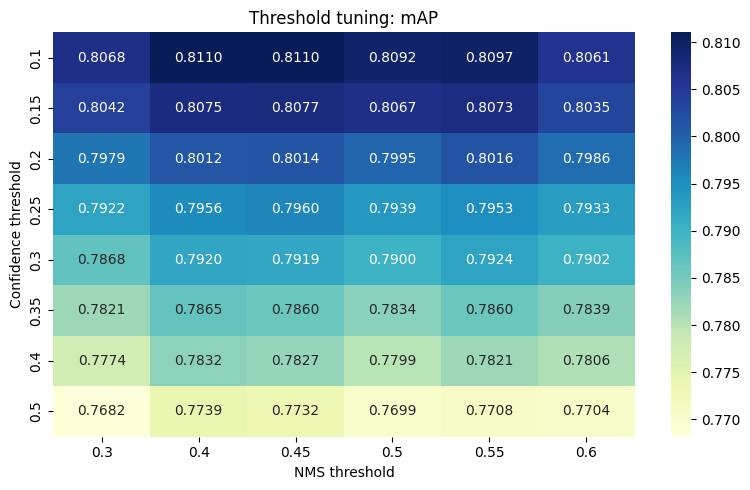

In [ ]:
if RAW_PREDICTIONS.exists():
    threshold_results = tune_prediction_thresholds(
        predictions_path=RAW_PREDICTIONS,
        ground_truth_path=GROUND_TRUTH,
        confidence_thresholds=[0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50],
        nms_thresholds=[0.30, 0.40, 0.45, 0.50, 0.55, 0.60],
    )
    display(threshold_results.head(15).round(4))
    save_dataframe(threshold_results, "threshold_tuning_results.csv")
    save_plot(plot_threshold_tuning_heatmap(threshold_results, metric="mAP"), "threshold_tuning_heatmap.png")
else:
    print(f"Không tìm thấy raw predictions: {RAW_PREDICTIONS}")